<a href="https://colab.research.google.com/github/annelizemendes/Estatistica-Bancaria/blob/main/An%C3%A1lise_da_Estat%C3%ADstica_Banc%C3%A1ria_(ESTBAN).ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Análise da Estatística Bancária (ESTBAN)

In [59]:
import pandas as pd
import matplotlib.pyplot as plt

uploaded = "/content/drive/MyDrive/ColabNotebook/dataset/202512_ESTBAN.CSV"

df = pd.read_csv(
    "202512_ESTBAN.CSV",
    sep=";",
    encoding="latin1",
    skiprows=2
)

## 1. Quais municípios possuem maior volume bancário?

In [ ]:
df = df.rename(columns={
    "VERBETE_399_TOTAL_DO_ATIVO": "TOTAL_DO_ATIVO"
})

df_ativo = df[[
    "MUNICIPIO",
    "UF",
    "TOTAL_DO_ATIVO"
]]

municipios_ativos = df.groupby(
    ["MUNICIPIO", "UF"]
)["TOTAL_DO_ATIVO"].sum()

municipios_ativos = municipios_ativos.sort_values(
    ascending=False
)

pd.options.display.float_format = '{:,.2f}'.format

municipios_ativos.head(10)

,,TOTAL_DO_ATIVO
MUNICIPIO,UF,
SAO PAULO,SP,"7,383,537,392,219.00"
BRASILIA,DF,"3,934,682,348,382.00"
OSASCO,SP,"1,804,786,565,081.00"
RIO DE JANEIRO,RJ,"1,765,350,957,419.00"
SAO BERNARDO DO CAMPO,SP,"824,877,279,223.00"
PORTO ALEGRE,RS,"487,582,937,627.00"
BELO HORIZONTE,MG,"475,515,331,842.00"
ARACAJU,SE,"413,113,791,366.00"
CURITIBA,PR,"233,775,482,494.00"


## 2. Comparar estados



Text(0.5, 1.0, 'Total do ativo por estado')

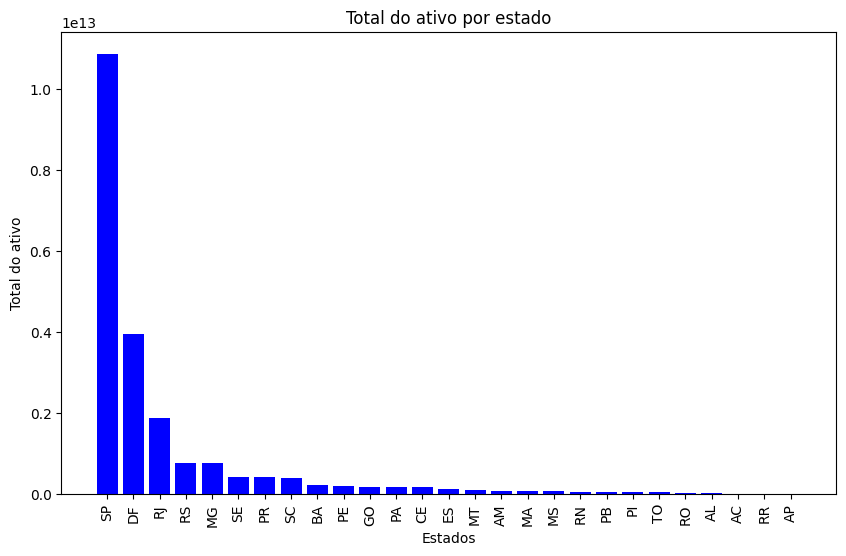

In [96]:
df = df.rename(columns={
    "VERBETE_399_TOTAL_DO_ATIVO": "TOTAL_DO_ATIVO"
})

ufs_ativos = df.groupby(
    ["UF"]
)["TOTAL_DO_ATIVO"].sum()

ufs_ativos = ufs_ativos.sort_values(
    ascending=False
)

x = ufs_ativos.index
y = ufs_ativos.values

plt.figure(figsize=(10, 6))
plt.bar(x, y, color="blue")
plt.xticks(rotation=90)
plt.xlabel("Estados")
plt.ylabel("Total do ativo")
plt.title("Total do ativo por estado")

## 3. Relação entre crédito e depósitos

Text(0.5, 1.0, 'Relação entre crédito e depósitos')

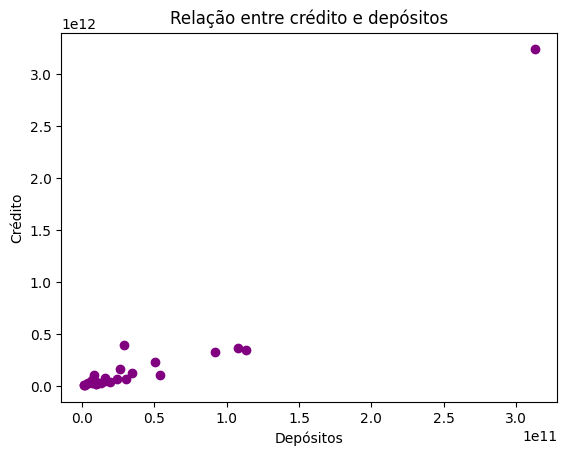

In [100]:
df = df.rename(columns={
    "VERBETE_160_OPERACOES_DE_CREDITO": "OPERACOES_DE_CREDITO",
    "VERBETE_420_DEPOSITOS_DE_POUPANCA": "DEPOSITOS_DE_POUPANCA"
})

ufs_financeiro = df.groupby("UF")[[
    "DEPOSITOS_DE_POUPANCA",
    "OPERACOES_DE_CREDITO"
]].sum()

x = ufs_financeiro["DEPOSITOS_DE_POUPANCA"]
y = ufs_financeiro["OPERACOES_DE_CREDITO"]

plt.scatter(x, y, color="purple")
plt.xlabel("Depósitos")
plt.ylabel("Crédito")
plt.title("Relação entre crédito e depósitos")